### **PROJET- EDS CONGO**: SANTE MATERNELLE DES FEMMES MARIEES EN REPUBLIQUE DEMOCRATIQUE DU CONGO

### **PARTIE A**:   ANALYSE STATISTIQUES SUR LA SANTE MATERNELLE PRECCISEMENT SUR L'ACCOUCHEMENT AVEC OU SANS ASSISTANCE D'UN PERSONEL QUALIFIE 

In [75]:
# importation des bibliotheques
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
# importation du dataset
dataIR=pd.read_stata("CDIR81FL.dta",convert_categoricals=True)

In [77]:
# affichage du dataset
dataIR.head()

,caseid,v000,v001,v002,v003,v004,v005,v006,v007,v008,...,s606ax_3,s606ax_4,s606ax_5,s606ax_6,s615c_1,s615c_2,s615c_3,s615c_4,s615c_5,s615c_6
0,1 8 2,CD8,1,8,2,1,203638,10,2023,1486,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1 24 2,CD8,1,24,2,1,203638,10,2023,1486,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1 35 1,CD8,1,35,1,1,203638,10,2023,1486,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1 38 1,CD8,1,38,1,1,203638,10,2023,1486,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1 38 3,CD8,1,38,3,1,203638,10,2023,1486,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
# taille du dataset
dataIR.shape

(27583, 5942)

###
Liste des variables :

* Identification et Pondération:
   - caseid
   - v005
   - v021 
   - v023
* Variable Dépendante (Santé Maternelle):
   - m3a: Docteur
   - m3b: Infirmière / Sage-femme 
   - m3c: Accoucheuse auxiliaire
   - m3d: Accoucheuse traditionnelle 
   - m3e: Parent / Ami
   - m3f: autres
   - m3g: Personnel ayant assisté
   
* Variables independantes 
   * caracteristique de la femme:
      - v013:  Âge en groupes
      - v024:  Région / Province
      - v025:  Milieu de résidence (Urbain/Rural)
      - v106:  Niveau d'éducation
      - v130:  Religion
      - v190:  Indice de richesse (Wealth index)
      - v717:  Occupation / Travail
      - v201:  Parité (Nombre total d'enfants nés)
      - v502:  Statut matrimonial (pour le filtrage) 
      - m14 : Nombre de visites prénatales (CPN)
   * Caractéristiques du Mari:
      - v701: Niveau d'éducation du mari
   * Exposition aux Médias
      - v157: Lecture de journaux
      - v158: Écoute de la radio
      - v159: Visionnage de la télévision
   * Autonomie Décisionnelle
      - v743a: Décision : Propres soins de santé
      - v743b: Décision : Gros achats ménagers
      - v743d:  Décision : Visites à la famille/parents


In [79]:
# Liste corrigée avec l'indice _1 pour les variables de maternité
variable_garde = [
    'caseid', 'v005', 'v021', 'v023', 
    'm3a_1', 'm3b_1', 'm3c_1', 'm3d_1', 'm3e_1', 'm3f_1', 'm3g_1','m14_1', 
    'v013', 'v024', 'v025', 'v106', 'v130', 'v190', 'v717', 'v201', 
    'v502', 'v701', 'v157', 'v158', 'v159', 'v743a', 'v743b', 'v743d']

# Création du nouveau dataset restreint
dataIRR = dataIR[variable_garde].copy()

In [80]:
# affichage du nouveau dataset
dataIRR.head()

,caseid,v005,v021,v023,m3a_1,m3b_1,m3c_1,m3d_1,m3e_1,m3f_1,...,v717,v201,v502,v701,v157,v158,v159,v743a,v743b,v743d
0,1 8 2,203638,1,mai-ndombe: rural,no,yes,NaN,NaN,NaN,NaN,...,agricultural - self employed,6,currently in union/living with a man,primary,not at all,not at all,not at all,respondent and husband/partner,respondent and husband/partner,respondent and husband/partner
1,1 24 2,203638,1,mai-ndombe: rural,no,yes,NaN,NaN,NaN,NaN,...,not working,2,currently in union/living with a man,secondary,not at all,not at all,not at all,respondent alone,husband/partner alone,respondent alone
2,1 35 1,203638,1,mai-ndombe: rural,NaN,NaN,NaN,NaN,NaN,NaN,...,agricultural - self employed,8,currently in union/living with a man,primary,not at all,not at all,not at all,respondent alone,respondent and husband/partner,respondent alone
3,1 38 1,203638,1,mai-ndombe: rural,NaN,NaN,NaN,NaN,NaN,NaN,...,agricultural - self employed,4,currently in union/living with a man,secondary,not at all,not at all,not at all,respondent alone,husband/partner alone,respondent alone
4,1 38 3,203638,1,mai-ndombe: rural,NaN,NaN,NaN,NaN,NaN,NaN,...,not working,0,never in union,NaN,not at all,not at all,not at all,NaN,NaN,NaN


In [81]:
dataIRR.shape

(27583, 28)

In [82]:
# verification des types
dataIRR.dtypes

caseid      object
v005         int32
v021         int16
v023      category
m3a_1     category
m3b_1     category
m3c_1     category
m3d_1     category
m3e_1     category
m3f_1     category
m3g_1     category
m14_1     category
v013      category
v024      category
v025      category
v106      category
v130      category
v190      category
v717      category
v201          int8
v502      category
v701      category
v157      category
v158      category
v159      category
v743a     category
v743b     category
v743d     category
dtype: object

In [83]:
# filtrage du dataset pour ne conserver que les femmes mariees
dataIRM=dataIRR[dataIRR['v502'].isin([1, 'currently in union/living with a man'])].copy()

In [84]:
dataIRM.head()

,caseid,v005,v021,v023,m3a_1,m3b_1,m3c_1,m3d_1,m3e_1,m3f_1,...,v717,v201,v502,v701,v157,v158,v159,v743a,v743b,v743d
0,1 8 2,203638,1,mai-ndombe: rural,no,yes,NaN,NaN,NaN,NaN,...,agricultural - self employed,6,currently in union/living with a man,primary,not at all,not at all,not at all,respondent and husband/partner,respondent and husband/partner,respondent and husband/partner
1,1 24 2,203638,1,mai-ndombe: rural,no,yes,NaN,NaN,NaN,NaN,...,not working,2,currently in union/living with a man,secondary,not at all,not at all,not at all,respondent alone,husband/partner alone,respondent alone
2,1 35 1,203638,1,mai-ndombe: rural,NaN,NaN,NaN,NaN,NaN,NaN,...,agricultural - self employed,8,currently in union/living with a man,primary,not at all,not at all,not at all,respondent alone,respondent and husband/partner,respondent alone
3,1 38 1,203638,1,mai-ndombe: rural,NaN,NaN,NaN,NaN,NaN,NaN,...,agricultural - self employed,4,currently in union/living with a man,secondary,not at all,not at all,not at all,respondent alone,husband/partner alone,respondent alone
6,1 49 2,203638,1,mai-ndombe: rural,no,no,NaN,NaN,NaN,NaN,...,agricultural - self employed,8,currently in union/living with a man,secondary,not at all,less than once a week,not at all,respondent and husband/partner,respondent and husband/partner,respondent and husband/partner


In [85]:
dataIRM.shape

(16938, 28)

In [86]:
# detection des valeurs manquantes
dataIRM.isna().sum()

caseid        0
v005          0
v021          0
v023          0
m3a_1      6576
m3b_1      6576
m3c_1     16938
m3d_1     16938
m3e_1     16938
m3f_1     16938
m3g_1      6576
m14_1      6576
v013          0
v024          0
v025          0
v106          0
v130          0
v190          0
v717          0
v201          0
v502          0
v701          0
v157          0
v158          0
v159          0
v743a         0
v743b         0
v743d         0
dtype: int64

In [87]:
# gestion des valeurs manquantes
# dataset sans NA
dataIRME=dataIRM.dropna(subset=["m3a_1"]).copy()

# dataset pour les predictions futures:
data_predict_futur=dataIRM[dataIRM['m3a_1'].isna()].copy()

In [88]:
# affiche du dataset apres correction des valeurs manquantes
dataIRME.isna().sum()

caseid        0
v005          0
v021          0
v023          0
m3a_1         0
m3b_1         0
m3c_1     10362
m3d_1     10362
m3e_1     10362
m3f_1     10362
m3g_1         0
m14_1         0
v013          0
v024          0
v025          0
v106          0
v130          0
v190          0
v717          0
v201          0
v502          0
v701          0
v157          0
v158          0
v159          0
v743a         0
v743b         0
v743d         0
dtype: int64

In [89]:
# detection des doublons
nb_doublons = dataIRME.duplicated().sum()
print(f"Nombre de lignes totalement identiques : {nb_doublons}")

Nombre de lignes totalement identiques : 0


In [90]:
# fonction de codage
def generation_sba(row):
    medecin=str(row["m3a_1"]).lower()
    sage_femme=str(row["m3b_1"]).lower()
    if "yes" in medecin or "yes" in sage_femme:
        return 1
    else:
        return 0

In [91]:
# creation d'une nouvelle colonne
dataIRME["SBA"]=dataIRME.apply(generation_sba, axis=1)

In [92]:
dataIRME.head()

,caseid,v005,v021,v023,m3a_1,m3b_1,m3c_1,m3d_1,m3e_1,m3f_1,...,v201,v502,v701,v157,v158,v159,v743a,v743b,v743d,SBA
0,1 8 2,203638,1,mai-ndombe: rural,no,yes,NaN,NaN,NaN,NaN,...,6,currently in union/living with a man,primary,not at all,not at all,not at all,respondent and husband/partner,respondent and husband/partner,respondent and husband/partner,1
1,1 24 2,203638,1,mai-ndombe: rural,no,yes,NaN,NaN,NaN,NaN,...,2,currently in union/living with a man,secondary,not at all,not at all,not at all,respondent alone,husband/partner alone,respondent alone,1
6,1 49 2,203638,1,mai-ndombe: rural,no,no,NaN,NaN,NaN,NaN,...,8,currently in union/living with a man,secondary,not at all,less than once a week,not at all,respondent and husband/partner,respondent and husband/partner,respondent and husband/partner,0
7,1 56 3,203638,1,mai-ndombe: rural,no,yes,NaN,NaN,NaN,NaN,...,1,currently in union/living with a man,secondary,not at all,not at all,not at all,respondent alone,respondent alone,respondent alone,1
10,1 80 2,203638,1,mai-ndombe: rural,no,no,NaN,NaN,NaN,NaN,...,2,currently in union/living with a man,secondary,not at all,not at all,not at all,respondent alone,husband/partner alone,respondent alone,0


In [93]:
# Convertir m14_1 en nombre (on remplace les erreurs ou textes par NaN, puis on met 0 pour les NaN)
dataIRME['cpn_visites'] = pd.to_numeric(dataIRME['m14_1'], errors='coerce').fillna(0)

# Vérification rapide du résultat
print(dataIRME['cpn_visites'].describe())

count    10362.000000
mean         2.943737
std          2.115071
min          0.000000
25%          1.000000
50%          3.000000
75%          4.000000
max         20.000000
Name: cpn_visites, dtype: float64


In [94]:
dataIRME.columns

Index(['caseid', 'v005', 'v021', 'v023', 'm3a_1', 'm3b_1', 'm3c_1', 'm3d_1',
       'm3e_1', 'm3f_1', 'm3g_1', 'm14_1', 'v013', 'v024', 'v025', 'v106',
       'v130', 'v190', 'v717', 'v201', 'v502', 'v701', 'v157', 'v158', 'v159',
       'v743a', 'v743b', 'v743d', 'SBA', 'cpn_visites'],
      dtype='object')

In [95]:
dataIRME['cpn_visites'].dtypes

dtype('float64')

In [96]:
# liste des colonnes a supprimer
col_delete=['m3a_1', 'm3b_1', 'm3c_1', 'm3d_1', 'm3e_1', 'm3f_1', 'm3g_1','m14_1', 'v502']
# suppression
data_finalIR=dataIRME.drop(columns=col_delete, errors="ignore")

In [97]:
data_finalIR.head()

,caseid,v005,v021,v023,v013,v024,v025,v106,v130,v190,...,v201,v701,v157,v158,v159,v743a,v743b,v743d,SBA,cpn_visites
0,1 8 2,203638,1,mai-ndombe: rural,45-49,mai-ndombe,rural,no education,jehovah witness,poorest,...,6,primary,not at all,not at all,not at all,respondent and husband/partner,respondent and husband/partner,respondent and husband/partner,1,4.0
1,1 24 2,203638,1,mai-ndombe: rural,20-24,mai-ndombe,rural,primary,no religion,poorer,...,2,secondary,not at all,not at all,not at all,respondent alone,husband/partner alone,respondent alone,1,3.0
6,1 49 2,203638,1,mai-ndombe: rural,40-44,mai-ndombe,rural,no education,catholic,poorest,...,8,secondary,not at all,less than once a week,not at all,respondent and husband/partner,respondent and husband/partner,respondent and husband/partner,0,1.0
7,1 56 3,203638,1,mai-ndombe: rural,20-24,mai-ndombe,rural,secondary,kimbanguiste,poorest,...,1,secondary,not at all,not at all,not at all,respondent alone,respondent alone,respondent alone,1,5.0
10,1 80 2,203638,1,mai-ndombe: rural,25-29,mai-ndombe,rural,secondary,protestant,poorer,...,2,secondary,not at all,not at all,not at all,respondent alone,husband/partner alone,respondent alone,0,3.0


In [98]:
data_finalIR.isna().sum()

caseid         0
v005           0
v021           0
v023           0
v013           0
v024           0
v025           0
v106           0
v130           0
v190           0
v717           0
v201           0
v701           0
v157           0
v158           0
v159           0
v743a          0
v743b          0
v743d          0
SBA            0
cpn_visites    0
dtype: int64

In [99]:
data_finalIR.shape

(10362, 21)

In [100]:
data_finalIR.columns

Index(['caseid', 'v005', 'v021', 'v023', 'v013', 'v024', 'v025', 'v106',
       'v130', 'v190', 'v717', 'v201', 'v701', 'v157', 'v158', 'v159', 'v743a',
       'v743b', 'v743d', 'SBA', 'cpn_visites'],
      dtype='object')

### Analyse exploratoire des donnees (EDA)

In [101]:
# poids d'echantillonage
data_finalIR['poids_final'] = data_finalIR['v005'] / 1000000

In [102]:
# proportion des poids ponderes
total_poids=data_finalIR["poids_final"].sum()
sba_pondere=data_finalIR.groupby("SBA")["poids_final"].sum()/total_poids

In [103]:
print("Répartition pondérée de l'accouchement qualifié (SBA) :")
print(sba_pondere * 100)

Répartition pondérée de l'accouchement qualifié (SBA) :
SBA
0    15.936285
1    84.063715
Name: poids_final, dtype: float64


In [104]:
data_finalIR["SBA"].dtypes

dtype('int64')

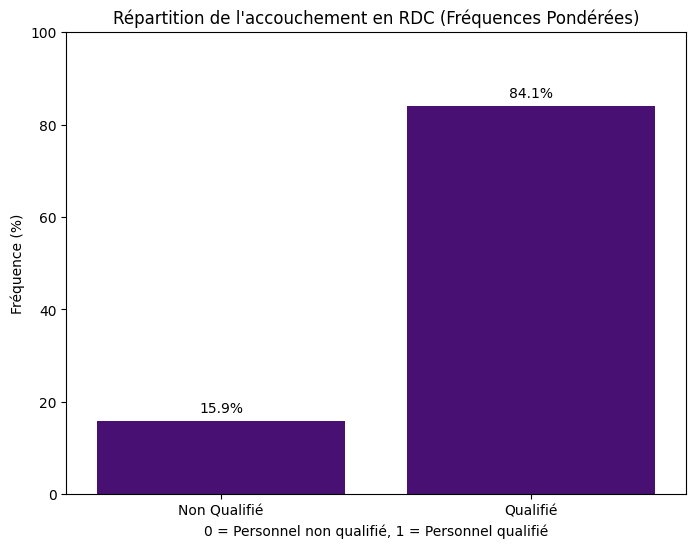

In [105]:
#  Calcul de la somme des poids par catégorie
sba_stats = data_finalIR.groupby('SBA')['poids_final'].sum().reset_index()

#  Conversion de la somme des poids en Fréquence (Pourcentage)
total_poids = sba_stats['poids_final'].sum()
sba_stats['frequence'] = (sba_stats['poids_final'] / total_poids) * 100

# Création du graphique
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=sba_stats, x="SBA", y="frequence", color="indigo")

#  Ajout des étiquettes de pourcentage au-dessus des barres
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

#  Personnalisation des axes
plt.title("Répartition de l'accouchement en RDC (Fréquences Pondérées)")
plt.xlabel("0 = Personnel non qualifié, 1 = Personnel qualifié")
plt.ylabel("Fréquence (%)")
plt.ylim(0, 100) # Pour que l'échelle soit sur 100%
plt.xticks(ticks=[0, 1], labels=["Non Qualifié", "Qualifié"])

plt.show()

### 
Analyse univariee des variables explicatives

In [106]:
from docx import Document
from docx.shared import Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH

# Préparation des statistiques 
exclure = ['SBA', 'poids_final', 'v005', 'caseid', 'v021', 'v023']
toutes_les_vars = [col for col in data_finalIR.columns if col not in exclure]

labels = {
    'v013': "Groupe d'âge", 'v025': "Milieu de résidence", 'v106': "Niveau d'éducation",
    'v190': "Quintile de richesse", 'v024': "Province / Région", 'v130': "Religion",
    'v717': "Occupation de la femme", 'v201': "Nombre d'enfants", 'v157': "Lecture Presse", 
    'v158': "Écoute Radio", 'v159': "Regarder TV", 'v743a': "Autonomie Santé", 
    'cpn_visites': "Consultations Prénatales"
}

# Création du document Word
doc = Document()
doc.add_heading("Tableau 1 : Caractéristiques socio-démographiques de l'échantillon", level=1)

# Création du tableau : (lignes = titre + données, colonnes = 3)
# On calcule d'abord le nombre total de lignes nécessaires
total_rows = 1 
for var in toutes_les_vars:
    total_rows += 1 + len(data_finalIR[var].unique())

table = doc.add_table(rows=1, cols=3)
table.style = 'Table Grid' # Style de base Word

# En-tête du tableau
hdr_cells = table.rows[0].cells
hdr_cells[0].text = 'Variable / Catégorie'
hdr_cells[1].text = 'Effectif brut (n)'
hdr_cells[2].text = 'Pourcentage pondéré (%)'

# Remplissage du tableau
total_poids = data_finalIR['poids_final'].sum()

for var in toutes_les_vars:
    libelle = labels.get(var, var)
    
    # Ligne de titre de la variable (en gras)
    row_cells = table.add_row().cells
    row_cells[0].text = libelle
    row_cells[0].paragraphs[0].runs[0].bold = True
    
    n_brut = data_finalIR[var].value_counts()
    poids_cat = data_finalIR.groupby(var)['poids_final'].sum()
    
    # Lignes des catégories
    for cat in n_brut.index:
        pct = (poids_cat[cat] / total_poids) * 100
        row_cells = table.add_row().cells
        row_cells[0].text = f"   {cat}" # Indentation pour la clarté
        row_cells[1].text = str(int(n_brut[cat]))
        row_cells[2].text = f"{pct:.1f}%"

# Sauvegarde 
file_name = "Tableau1_Univarie_RDC.docx"
doc.save(file_name)
print(f"Le fichier Word '{file_name}' a été créé avec succès !")

C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_28100\2747021082.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  poids_cat = data_finalIR.groupby(var)['poids_final'].sum()
C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_28100\2747021082.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  poids_cat = data_finalIR.groupby(var)['poids_final'].sum()
C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_28100\2747021082.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ad

Le fichier Word 'Tableau1_Univarie_RDC.docx' a été créé avec succès !


C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_28100\2747021082.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  poids_cat = data_finalIR.groupby(var)['poids_final'].sum()
C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_28100\2747021082.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  poids_cat = data_finalIR.groupby(var)['poids_final'].sum()
C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_28100\2747021082.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ad

C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_28100\3434740063.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_28100\3434740063.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_affichage, rotation=45, ha="right")


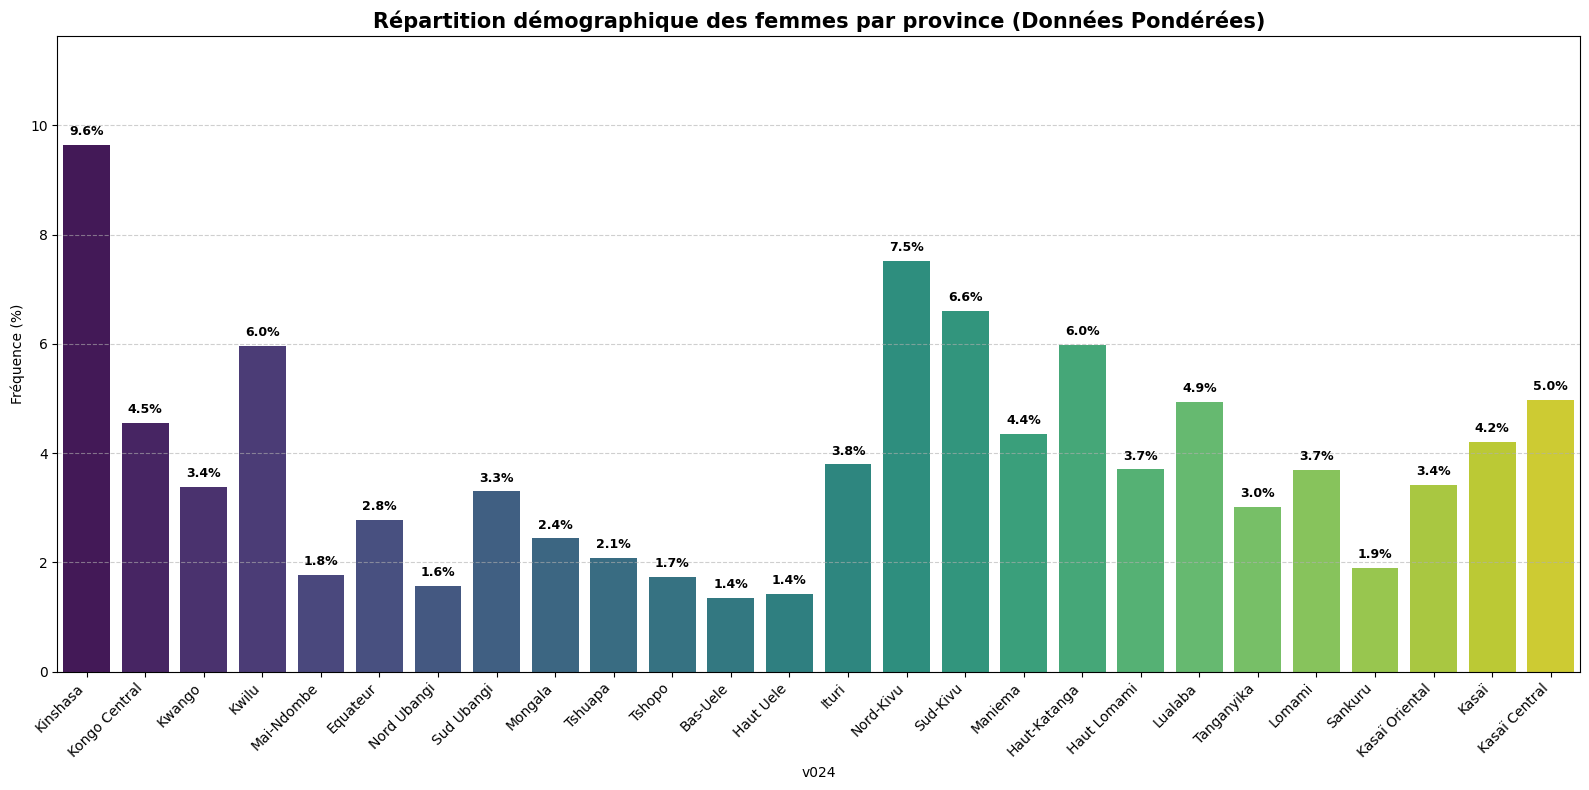

In [107]:
#PRÉPARATION DES DONNÉES (On travaille sur les noms directement)
# On s'assure que les noms correspondent bien à votre liste (ex: tout en minuscule ou propre)
data_finalIR['v024'] = data_finalIR['v024'].astype(str).str.strip()

# CALCUL PONDÉRÉ
prov_weighted = data_finalIR.groupby('v024')['poids_final'].sum().reset_index()
total_poids = prov_weighted['poids_final'].sum()
prov_weighted['pourcentage'] = (prov_weighted['poids_final'] / total_poids) * 100

# VOTRE LISTE DE RÉFÉRENCE (Vérifiez bien l'orthographe exacte dans vos données)

provinces_ordre = [
    "kinshasa", "kongo central", "kwango", "kwilu", "mai-ndombe", "equateur", 
    "nord ubangi", "sud ubangi", "mongala", "tshuapa", "tshopo", "bas-uele", 
    "haut uele", "ituri", "nord-kivu", "sud-kivu", "maniema", "haut-katanga", 
    "haut lomami", "lualaba", "tanganyika", "lomami", "sankuru", 
    "kasaï oriental", "kasaï", "kasaï central"
]

# CRÉATION DU GRAPHIQUE
plt.figure(figsize=(16, 8))

# Utilisation de 'order' avec la liste de noms pour éviter le graphique vide
ax = sns.barplot(
    data=prov_weighted, 
    x="v024", 
    y="pourcentage", 
    palette="viridis",
    order=provinces_ordre  # C'est ici que l'ordre est imposé
)

# ESTHÉTIQUE DES LABELS
labels_affichage = [p.title() for p in provinces_ordre]
ax.set_xticklabels(labels_affichage, rotation=45, ha="right")

# ANNOTATIONS (Pourcentages au-dessus des barres)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=9, fontweight='bold')

plt.title("Répartition démographique des femmes par province (Données Pondérées)", fontsize=15, fontweight='bold')
plt.ylabel("Fréquence (%)")
plt.ylim(0, prov_weighted['pourcentage'].max() + 2)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_28100\3944729956.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  educ_weighted = data_finalIR.groupby('v106')['poids_final'].sum().reset_index()


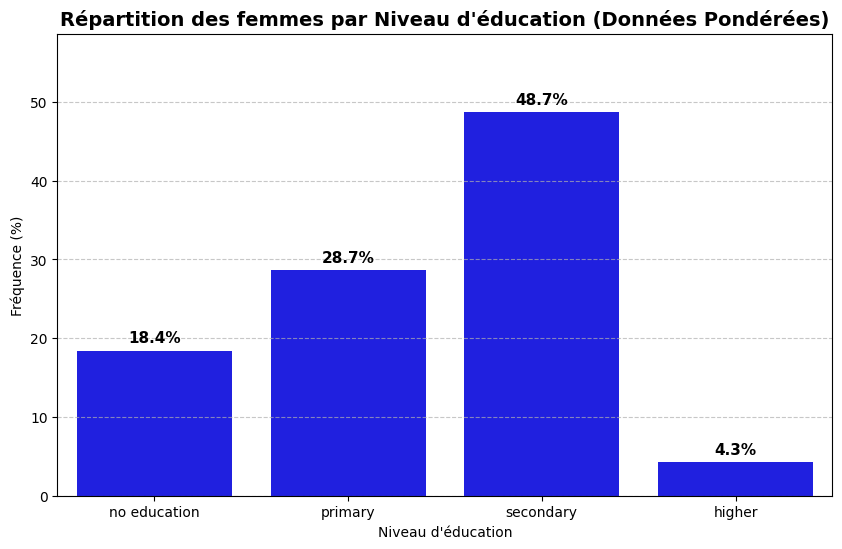

In [108]:
# PRÉPARATION DES DONNÉES PONDÉRÉES
# On fait la somme des poids par niveau d'éducation (v106)
educ_weighted = data_finalIR.groupby('v106')['poids_final'].sum().reset_index()

# CALCUL DES POURCENTAGES RÉELS (Méthode Sanni Yaya)
total_poids = educ_weighted['poids_final'].sum()
educ_weighted['pourcentage'] = (educ_weighted['poids_final'] / total_poids) * 100

# CRÉATION DU GRAPHIQUE
plt.figure(figsize=(10, 6))
# On utilise sns.barplot au lieu de countplot pour forcer l'usage du calcul pondéré
ax = sns.barplot(data=educ_weighted, x="v106", y="pourcentage", color="blue")

# CONFIGURATION DES AXES
plt.title("Répartition des femmes par Niveau d'éducation (Données Pondérées)", fontsize=14, fontweight='bold')
plt.xlabel("Niveau d'éducation")
plt.ylabel("Fréquence (%)")

# AJOUT DES ÉTIQUETTES (Labels) EXACTES DU TABLEAU
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

# Ajustement de l'axe Y pour laisser de la place au texte
plt.ylim(0, educ_weighted['pourcentage'].max() + 10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_28100\2360724674.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wealth_weighted = data_finalIR.groupby('v190')['poids_final'].sum().reset_index()
C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_28100\2360724674.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Plus pauvre", "Pauvre", "Moyen", "Riche", "Plus riche"])


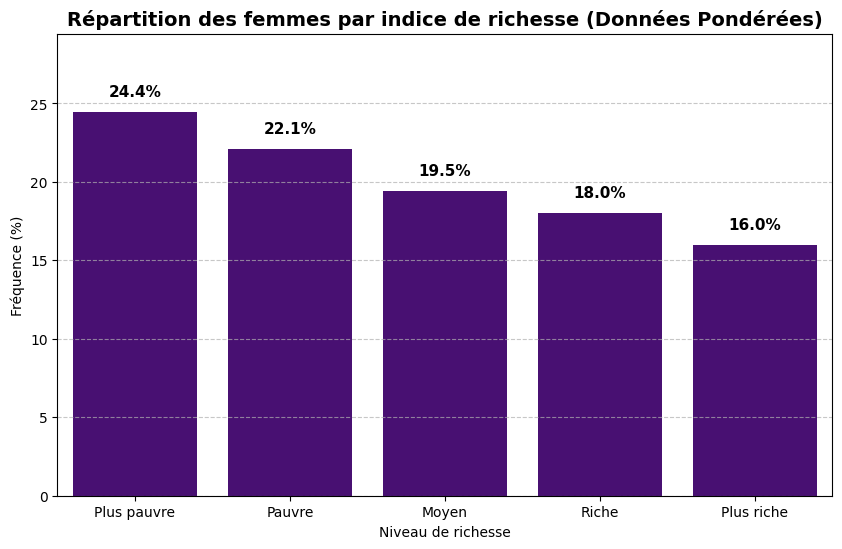

In [109]:
# RÉPARATION DES DONNÉES PONDÉRÉES
wealth_weighted = data_finalIR.groupby('v190')['poids_final'].sum().reset_index()

# Calcul du pourcentage
total_poids = wealth_weighted['poids_final'].sum()
wealth_weighted['pourcentage'] = (wealth_weighted['poids_final'] / total_poids) * 100

# ORDRE DES CATÉGORIES (Vérifie si tes données sont en minuscules comme pour Kinshasa)
wealth_order = ["poorest", "poorer", "middle", "richer", "richest"]

# CRÉATION DU GRAPHIQUE
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=wealth_weighted, 
    x="v190", 
    y="pourcentage", 
    color="indigo",
    order=wealth_order
)

# ESTHÉTIQUE ET LABELS
ax.set_xticklabels(["Plus pauvre", "Pauvre", "Moyen", "Riche", "Plus riche"])
plt.title("Répartition des femmes par indice de richesse (Données Pondérées)", fontsize=14, fontweight='bold')
plt.xlabel("Niveau de richesse")
plt.ylabel("Fréquence (%)")

# AJOUT DES ÉTIQUETTES (Exactement comme dans ton tableau)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

plt.ylim(0, wealth_weighted['pourcentage'].max() + 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

###
Analyse bivariee

In [110]:
from scipy.stats import chi2_contingency
from docx import Document

# Préparation
exclure = ['SBA', 'poids_final', 'v005', 'caseid', 'v021', 'v023']
variables_indep = [col for col in data_finalIR.columns if col not in exclure]

doc = Document()
doc.add_heading("Tableau 2 : Caractéristiques des participantes et recours à l'accouchement qualifié", level=1)

# Création du tableau avec 5 colonnes
table = doc.add_table(rows=1, cols=5)
table.style = 'Table Grid'
hdr_cells = table.rows[0].cells
hdr_cells[0].text = 'Variable / Catégorie'
hdr_cells[1].text = 'Non Qualifié % (N*)'
hdr_cells[2].text = 'Qualifié % (N*)'
hdr_cells[3].text = 'Total (N*)'
hdr_cells[4].text = 'p-value'

# *N = Effectifs pondérés

# Boucle de croisement
for var in variables_indep:
    # CALCULS PONDÉRÉS 
    # On crée un tableau croisé pondéré (Effectifs)
    # On multiplie chaque observation par son poids
    ct_weighted = pd.crosstab(
        index=data_finalIR[var], 
        columns=data_finalIR['SBA'], 
        values=data_finalIR['poids_final'], 
        aggfunc='sum'
    ).fillna(0)
    
    # Calcul des pourcentages par ligne (normalize='index')
    perc_weighted = ct_weighted.div(ct_weighted.sum(axis=1), axis=0) * 100
    
    #  TEST STATISTIQUE (sur effectifs bruts) 
    contingency = pd.crosstab(data_finalIR[var], data_finalIR['SBA'])
    chi2, p, dof, ex = chi2_contingency(contingency)
    
    # REMPLISSAGE DU TABLEAU WORD 
    # Ligne de titre pour la variable
    row_cells = table.add_row().cells
    row_cells[0].text = var.upper()
    row_cells[0].paragraphs[0].runs[0].bold = True
    # Affichage de la p-value (avec formatage pour les très petites valeurs)
    p_text = "< 0.001" if p < 0.001 else f"{p:.3f}"
    row_cells[4].text = p_text
    
    # Ajout des catégories de la variable
    for cat in ct_weighted.index:
        cat_cells = table.add_row().cells
        
        # Nom de la catégorie
        cat_cells[0].text = f"   {cat}"
        
        # Non Qualifié (SBA = 0)
        n_0 = ct_weighted.loc[cat, 0]
        p_0 = perc_weighted.loc[cat, 0]
        cat_cells[1].text = f"{p_0:.1f}% ({int(n_0)})"
        
        # Qualifié (SBA = 1)
        n_1 = ct_weighted.loc[cat, 1]
        p_1 = perc_weighted.loc[cat, 1]
        cat_cells[2].text = f"{p_1:.1f}% ({int(n_1)})"
        
        # Total
        total_n = n_0 + n_1
        cat_cells[3].text = f"{int(total_n)}"

# Sauvegarde
doc.save("Tableau2_Bivarie_Yaya_Style.docx")
print("Tableau bivarié complet généré avec succès !")

Tableau bivarié complet généré avec succès !


In [111]:
# encodage des variables categorielles
# Définition des dictionnaires de correspondance (Mappings)
mappings = {
    'v013': {"15-19": 1, "20-24": 2, "25-29": 3, "30-34": 4, "35-39": 5, "40-44": 6, "45-49": 7},
    
    'v024': {
        "kinshasa": 1, "kongo central": 2, "kwango": 3, "kwilu": 4, "mai-ndombe": 5,
        "equateur": 6, "nord ubangi": 7, "sud ubangi": 8, "mongala": 9, "tshuapa": 10,
        "tshopo": 11, "bas-uele": 12, "haut uele": 13, "ituri": 14, "nord-kivu": 15,
        "sud-kivu": 16, "maniema": 17, "haut-katanga": 18, "haut lomami": 19,
        "lualaba": 20, "tanganyika": 21, "lomami": 22, "sankuru": 23,
        "kasaï oriental": 24, "kasaï": 25, "kasaï central": 26
    },
    
    'v025': {"urban": 1, "rural": 2},
    
    'v106': {"no education": 0, "primary": 1, "secondary": 2, "higher": 3},
    
    'v130': {
        "catholic": 1, "protestant": 2, "salvation army": 3, "kimbanguiste": 4,
        "muslim": 5, "non denominational/charismatic/apostolic": 6,
        "jehovah witness": 7, "animist/traditional religion": 8,
        "no religion": 9, "other": 96
    },
    
    'v190': {"poorest": 1, "poorer": 2, "middle": 3, "richer": 4, "richest": 5},
    
    'v717': {
        "not working": 0, "professional/technical/managerial": 1, "clerical": 2,
        "agricultural - self employed": 4, "household and domestic": 6,
        "services": 7, "skilled manual": 8, "unskilled manual": 9, "don't know": 98
    },
    
    'v701': {"no education": 0, "primary": 1, "secondary": 2, "higher": 3, "don't know": 8},
    
    'v157': {"not at all": 0, "less than once a week": 1, "at least once a week": 2},
    'v158': {"not at all": 0, "less than once a week": 1, "at least once a week": 2},
    'v159': {"not at all": 0, "less than once a week": 1, "at least once a week": 2},
    
    'v743a': {"respondent alone": 1, "respondent and husband/partner": 2, "husband/partner alone": 4, "someone else": 5, "other": 6},
    'v743b': {"respondent alone": 1, "respondent and husband/partner": 2, "husband/partner alone": 4, "someone else": 5, "other": 6},
    'v743d': {"respondent alone": 1, "respondent and husband/partner": 2, "husband/partner alone": 4, "someone else": 5, "other": 6}
}

# Application de l'encodage
data_encoded = data_finalIR.copy()

for var, mapping in mappings.items():
    # On met en minuscule et on enlève les espaces inutiles pour assurer la correspondance
    if data_encoded[var].dtype == 'object' or data_encoded[var].dtype.name == 'category':
        data_encoded[var] = data_encoded[var].astype(str).str.lower().str.strip()
        data_encoded[var] = data_encoded[var].map(mapping)

# Vérification des valeurs manquantes (si un nom n'était pas dans le dictionnaire)
for var in mappings.keys():
    nan_count = data_encoded[var].isna().sum()
    if nan_count > 0:
        print(f"Attention : {nan_count} valeurs n'ont pas pu être encodées pour {var}")

print("Encodage terminé avec succès.")

Encodage terminé avec succès.


In [112]:
data_encoded.dtypes

caseid           object
v005              int32
v021              int16
v023           category
v013              int64
v024              int64
v025              int64
v106              int64
v130              int64
v190              int64
v717              int64
v201               int8
v701              int64
v157              int64
v158              int64
v159              int64
v743a             int64
v743b             int64
v743d             int64
SBA               int64
cpn_visites     float64
poids_final     float64
dtype: object

In [113]:
# Liste des variables à convertir
vars_cat = ['v013', 'v024', 'v025', 'v106', 'v130', 'v190', 
            'v717', 'v701', 'v157', 'v158', 'v159', 
            'v743a', 'v743b', 'v743d']

# Application sur data_encoded
for col in vars_cat:
    data_encoded[col] = data_encoded[col].astype('category')

# Vérification finale
print("Types des colonnes dans data_encoded :")
print(data_encoded[vars_cat].dtypes)

Types des colonnes dans data_encoded :
v013     category
v024     category
v025     category
v106     category
v130     category
v190     category
v717     category
v701     category
v157     category
v158     category
v159     category
v743a    category
v743b    category
v743d    category
dtype: object


In [114]:
data_encoded.dtypes

caseid           object
v005              int32
v021              int16
v023           category
v013           category
v024           category
v025           category
v106           category
v130           category
v190           category
v717           category
v201               int8
v701           category
v157           category
v158           category
v159           category
v743a          category
v743b          category
v743d          category
SBA               int64
cpn_visites     float64
poids_final     float64
dtype: object

In [115]:
data_encoded.shape

(10362, 22)

C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_28100\759169125.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_weighted = data_finalIR.groupby(['v025', 'SBA'])['poids_final'].sum().reset_index()
C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_28100\759169125.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_weighted['pourcentage'] = df_weighted.groupby('v025')['poids_final'].transform(lambda x: (x / x.sum()) * 100)
C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_28100\759169125.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or usin

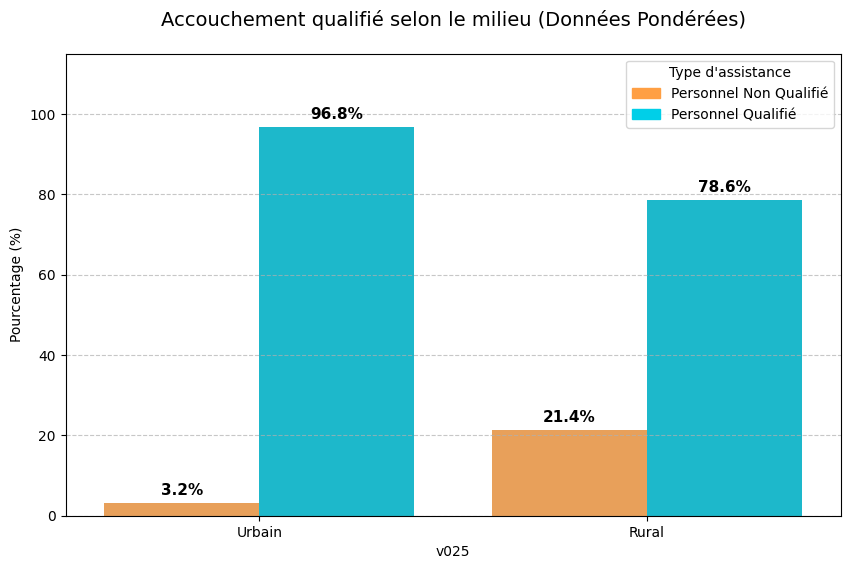

In [116]:
import matplotlib.patches as mpatches

# CALCUL PONDÉRÉ : On fait la somme des poids au lieu de compter les lignes
# On groupe par milieu (v025) et par SBA
df_weighted = data_finalIR.groupby(['v025', 'SBA'])['poids_final'].sum().reset_index()

# CALCUL DES POURCENTAGES : On divise la somme des poids de chaque groupe 
# par la somme totale des poids du milieu de résidence
df_weighted['pourcentage'] = df_weighted.groupby('v025')['poids_final'].transform(lambda x: (x / x.sum()) * 100)

# CONFIGURATION DU GRAPHIQUE
couleurs = {0: "#FF9F43", 1: "#00CFE8"} # Orange=Non Qualifié, Bleu=Qualifié

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_weighted, 
    x="v025", 
    y="pourcentage", 
    hue="SBA", 
    palette=couleurs
)

# Correction des labels (1=Urbain, 2=Rural selon l'EDS)
ax.set_xticklabels(["Urbain", "Rural"])

# Légende
orange_patch = mpatches.Patch(color='#FF9F43', label='Personnel Non Qualifié')
blue_patch = mpatches.Patch(color='#00CFE8', label='Personnel Qualifié')
plt.legend(handles=[orange_patch, blue_patch], title="Type d'assistance", loc='upper right')

# Ajout des étiquettes (qui correspondront maintenant à 96.8% et 78.6%)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

plt.title("Accouchement qualifié selon le milieu (Données Pondérées)", fontsize=14, pad=20)
plt.ylabel("Pourcentage (%)")
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_28100\4015498743.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Plus pauvres", "Pauvres", "Moyen", "Riches", "Plus riches"])


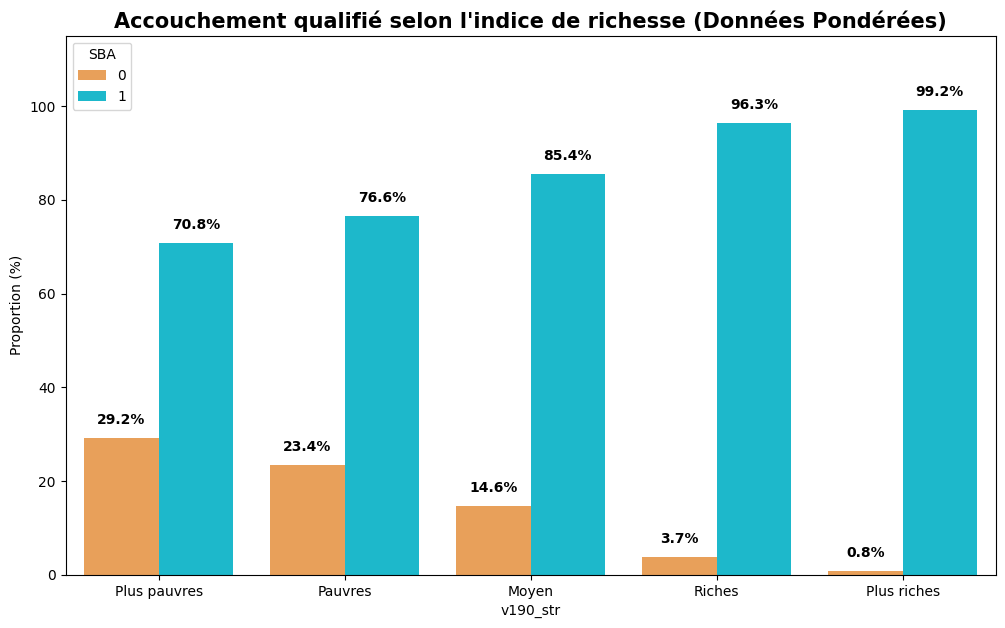

In [117]:
import matplotlib.patches as mpatches

#NETTOYAGE ET CALCUL PONDÉRÉ

data_finalIR['v190_str'] = data_finalIR['v190'].astype(str).str.lower().str.strip()

# Calcul de la somme des poids
df_richesse = data_finalIR.groupby(['v190_str', 'SBA'])['poids_final'].sum().reset_index()

# Calcul des pourcentages par quintile
df_richesse['pourcentage'] = df_richesse.groupby('v190_str')['poids_final'].transform(lambda x: (x / x.sum()) * 100)

# 2. ORDRE LOGIQUE (On utilise les noms tels qu'ils apparaissent dans votre erreur)
# Vérifiez bien si vos données utilisent "poorest" ou "plus pauvres"
ordre_richesse = ["poorest", "poorer", "middle", "richer", "richest"]

# CRÉATION DU GRAPHIQUE
plt.figure(figsize=(12, 7))
couleurs = {0: "#FF9F43", 1: "#00CFE8"}

ax = sns.barplot(
    data=df_richesse, 
    x="v190_str", 
    y="pourcentage", 
    hue="SBA", 
    palette=couleurs,
    order=ordre_richesse
)

# ÉTIQUETTES ET ESTHÉTIQUE
ax.set_xticklabels(["Plus pauvres", "Pauvres", "Moyen", "Riches", "Plus riches"])
plt.title("Accouchement qualifié selon l'indice de richesse (Données Pondérées)", fontsize=15, fontweight='bold')
plt.ylabel("Proportion (%)")

# Ajout des chiffres au-dessus des barres (doivent correspondre à 29.2%, 23.4%, etc.)
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.1f}%', 
                    (p.get_x() + p.get_width() / 2., h), 
                    ha='center', va='bottom', 
                    xytext=(0, 8), textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.ylim(0, 115)
plt.show()

In [118]:
# Suppression de la colonne v023 (puisque vide et non requise)
if 'v023' in data_encoded.columns:
    data_encoded = data_encoded.drop(columns=['v023'])

# Vérification que v021 et poids_final sont bien là
colonnes_essentielles = ['v021', 'poids_final', 'SBA']
print("Vérification des variables clés :")
print(data_encoded[colonnes_essentielles].describe())

Vérification des variables clés :
               v021   poids_final           SBA
count  10362.000000  10362.000000  10362.000000
mean     390.695136      0.891877      0.772438
std      225.884840      1.047879      0.419279
min        1.000000      0.009932      0.000000
25%      195.000000      0.239395      1.000000
50%      394.000000      0.535032      1.000000
75%      586.000000      1.120077      1.000000
max      780.000000      7.945959      1.000000


In [119]:
# Exportation finale
data_encoded.to_csv('CDIR81FL.csv', index=False, sep=';')
data_encoded.to_excel('CDIR81FL.xlsx', index=False)

## FIN DE L'ANALYSE 